In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("vgsales.csv")

# df = df.dropna(axis=1)
df.isna().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [5]:
df = df.dropna(subset=['Year', 'Publisher']).copy()
df.isna().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

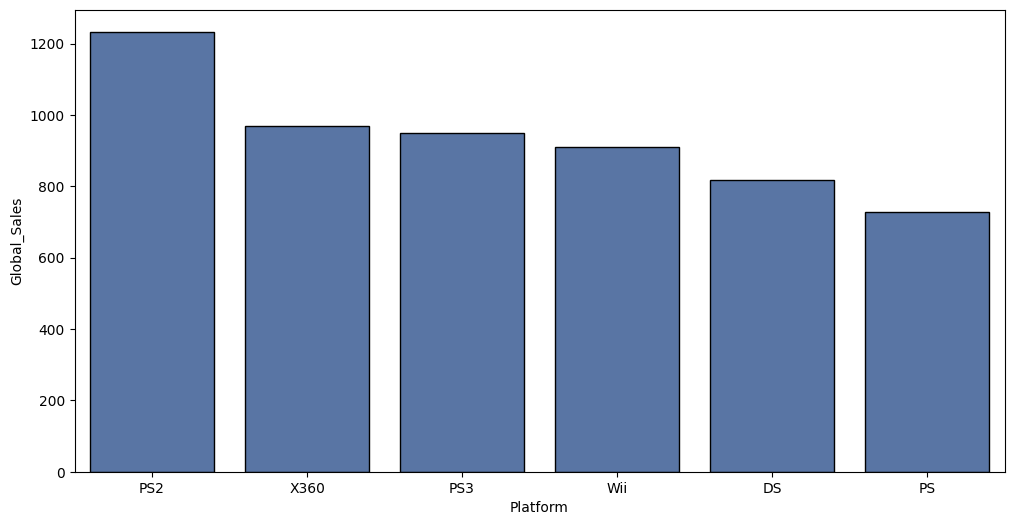

In [6]:
platforms = df.groupby(['Platform'], as_index=False)['Global_Sales'].sum()
top_20 = platforms[platforms['Global_Sales'] > platforms['Global_Sales'].quantile(0.8)].sort_values('Global_Sales', ascending=False)

plt.figure(figsize=(12, 6))
sns.set_palette("deep")
sns.barplot(data=top_20, x='Platform', y='Global_Sales', edgecolor="black")
plt.show()

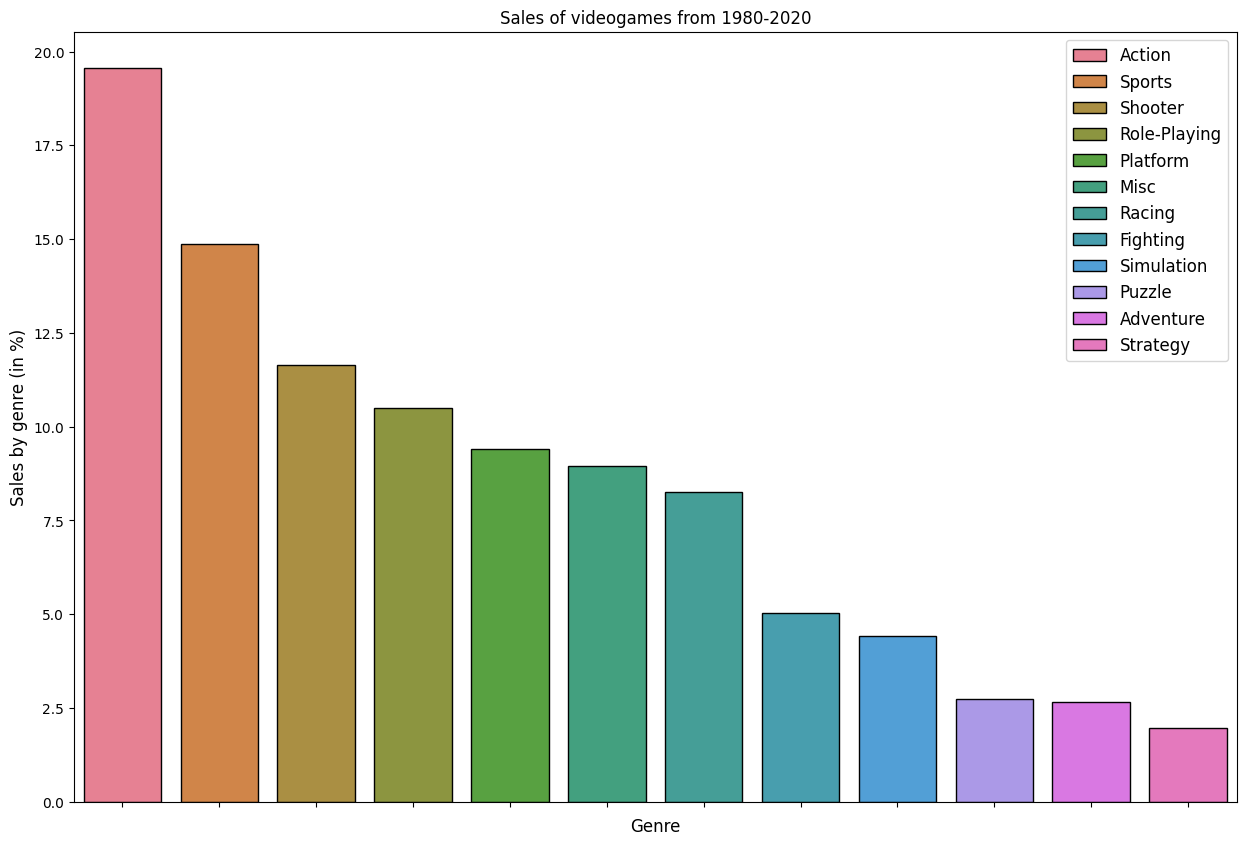

In [7]:
genre_distr = df.groupby(['Genre'], as_index=False)['Global_Sales'].sum().sort_values('Global_Sales', ascending=False).copy()
genre_distr['Global_Sales'] = 100*genre_distr['Global_Sales']/genre_distr['Global_Sales'].sum()

plt.figure(figsize=(15, 10))
sns.set_palette("deep")
sns.barplot(data=genre_distr, x='Genre', y='Global_Sales', hue='Genre', edgecolor="black", legend="full").set(xticklabels=[])
plt.xlabel('Genre', fontsize=12)
plt.legend(loc='best', fontsize=12)

plt.title("Sales of videogames from 1980-2020")
plt.ylabel('Sales by genre (in %)', fontsize=12)
plt.xticks(rotation=45, fontsize=8)
plt.show()

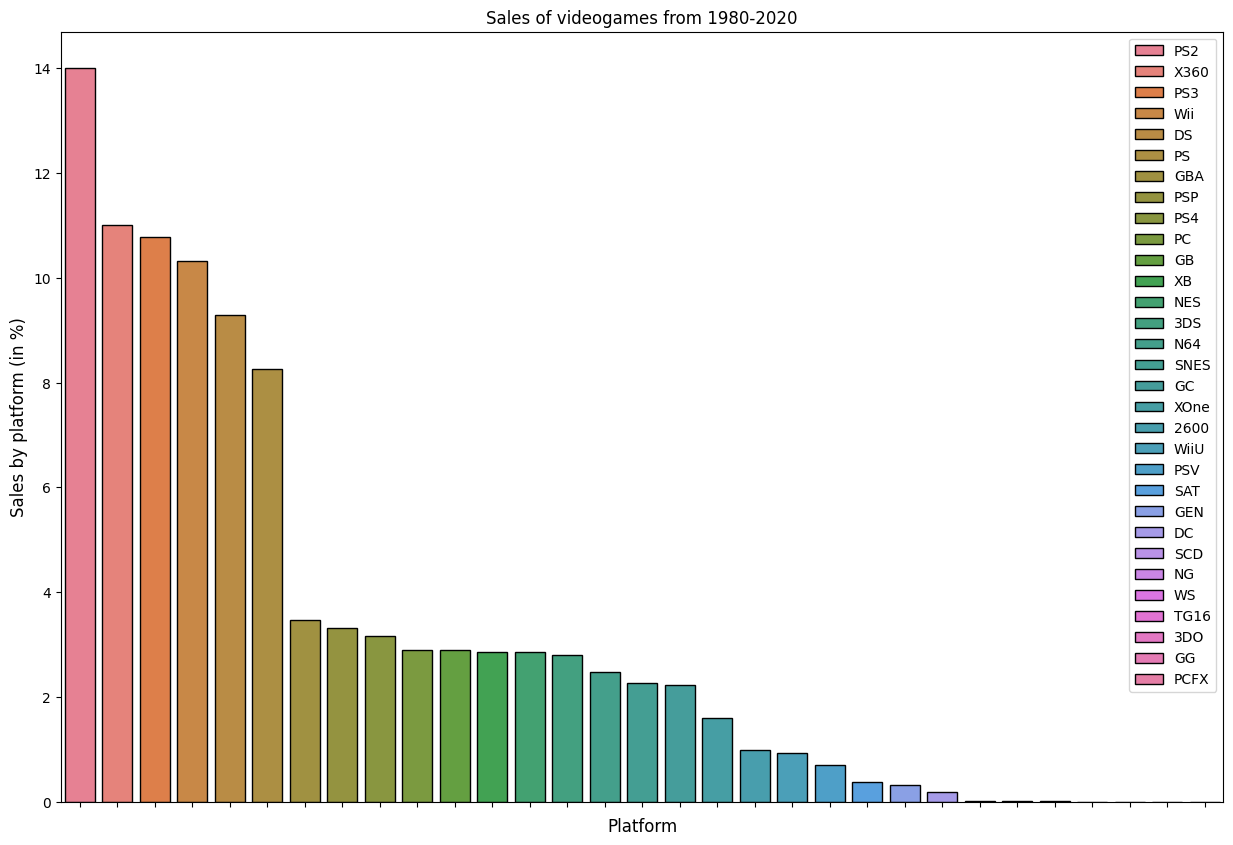

In [8]:
platform_distr = df.groupby(['Platform'], as_index=False)['Global_Sales'].sum().sort_values('Global_Sales', ascending=False).copy()
platform_distr['Global_Sales'] = 100*platform_distr['Global_Sales']/platform_distr['Global_Sales'].sum()

plt.figure(figsize=(15, 10))
sns.set_palette("deep")
sns.barplot(data=platform_distr, x='Platform', y='Global_Sales', hue='Platform', edgecolor="black", legend="full").set(xticklabels=[])
plt.xlabel('Platform', fontsize=12)
plt.legend(loc='best', fontsize=10)

plt.title("Sales of videogames from 1980-2020")
plt.ylabel('Sales by platform (in %)', fontsize=12)
plt.xticks(rotation=45, fontsize=8)
plt.show()

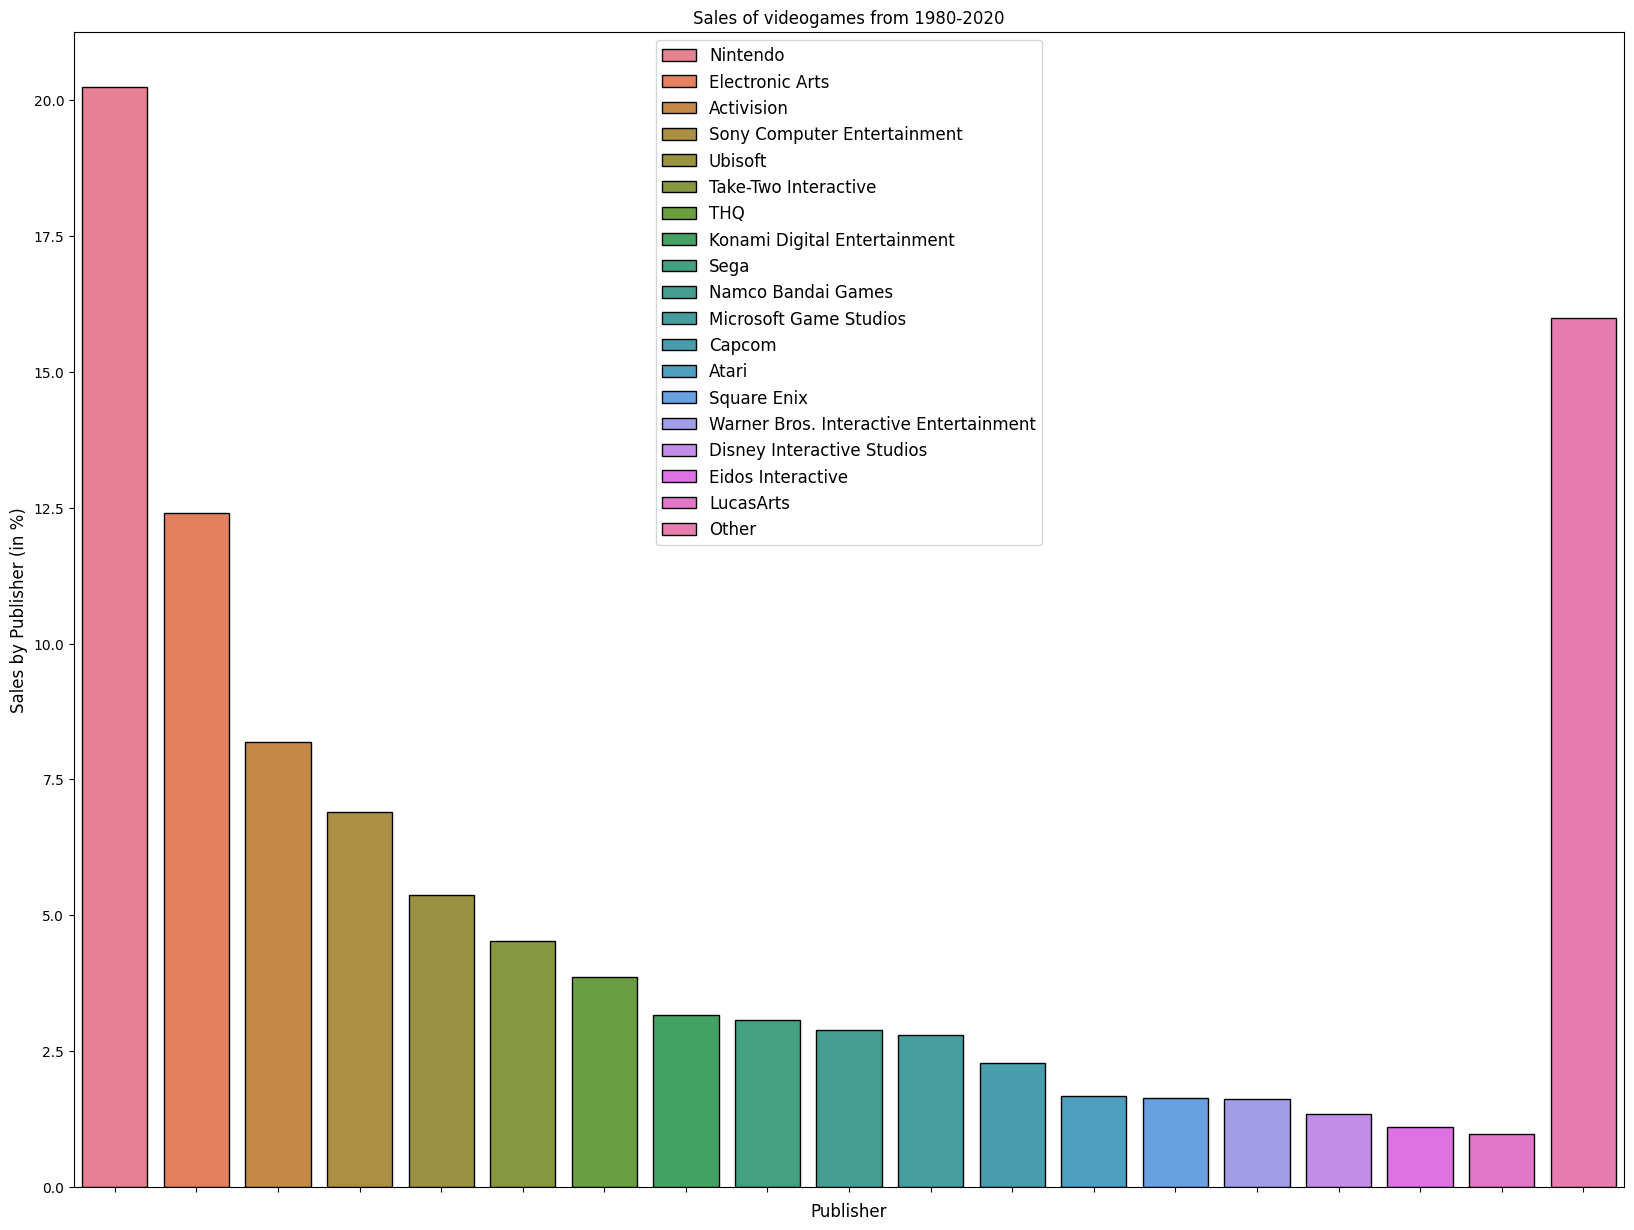

In [9]:
publisher_distr = df.groupby(['Publisher'], as_index=False)['Global_Sales'].sum().sort_values('Global_Sales', ascending=False).copy()

other = publisher_distr[publisher_distr['Global_Sales'] <= publisher_distr['Global_Sales'].quantile(0.97)]

publisher_distr = publisher_distr[publisher_distr['Global_Sales'] > publisher_distr['Global_Sales'].quantile(0.97)]

publisher_distr.loc[len(publisher_distr)] = ['Other', other['Global_Sales'].sum()]

publisher_distr['Global_Sales'] = 100*publisher_distr['Global_Sales']/publisher_distr['Global_Sales'].sum()

plt.figure(figsize=(20, 15))
sns.set_palette("deep")
ax = sns.barplot(data=publisher_distr, x='Publisher', y='Global_Sales', hue="Publisher", dodge=False, edgecolor="black", legend="full").set(xticklabels=[])
plt.xlabel('Publisher', fontsize=12)
plt.legend(loc='best', fontsize=12)

plt.title("Sales of videogames from 1980-2020")
plt.ylabel('Sales by Publisher (in %)', fontsize=12)
plt.xticks(rotation=50, fontsize=7)
plt.show()


In [10]:
hit_Games = df.sort_values('Global_Sales', ascending=False)
hit_Games = hit_Games[hit_Games['Global_Sales'] > hit_Games['Global_Sales'].quantile(0.8)]
hit_Games.head(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


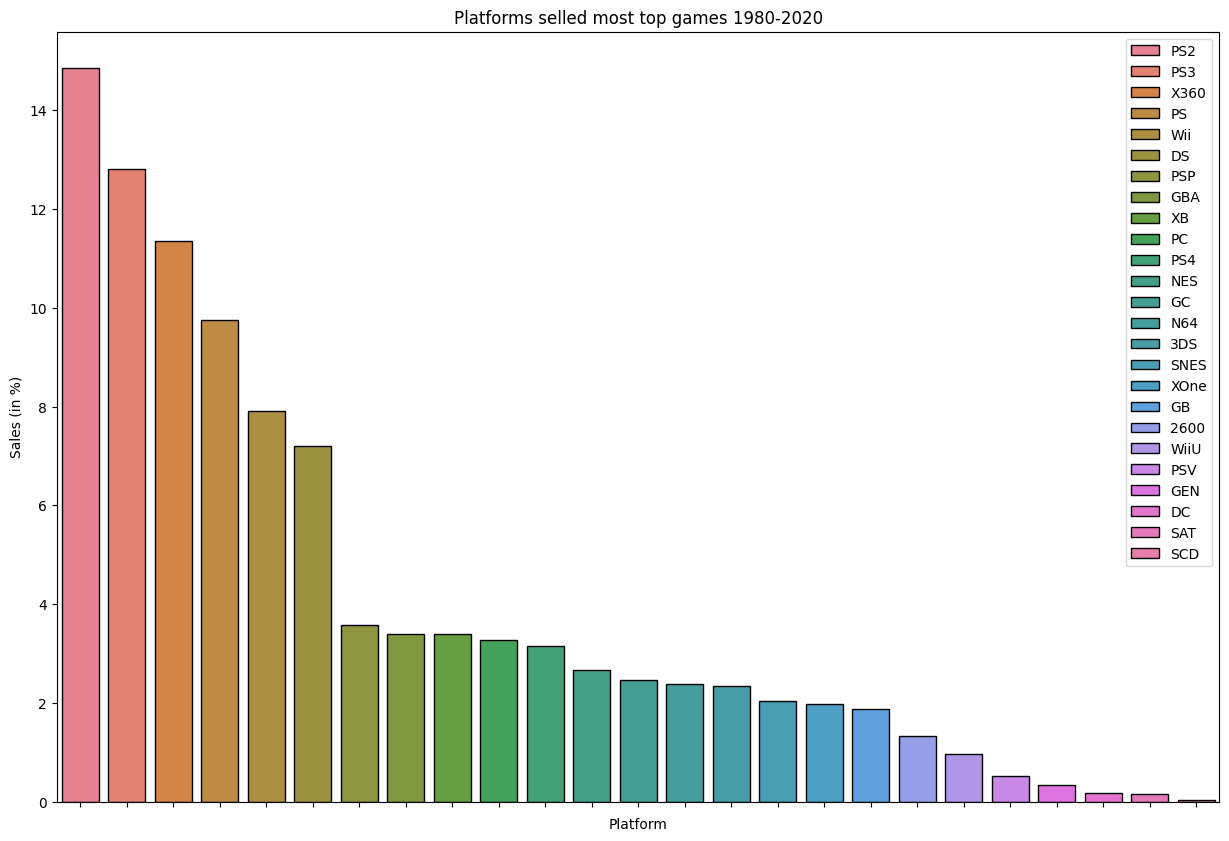

In [11]:
hit_Games_platform = hit_Games['Platform'].value_counts().reset_index()
hit_Games_platform.columns = ['Platform', 'Top_Games_Count']
hit_Games_platform['Top_Games_Count'] = 100*hit_Games_platform['Top_Games_Count']/hit_Games_platform['Top_Games_Count'].sum()

plt.figure(figsize = (15, 10))
sns.set_palette("deep")
sns.barplot(data = hit_Games_platform, x='Platform', y='Top_Games_Count', hue='Platform', edgecolor="black", legend="full").set(xticklabels=[])
plt.legend(loc='best')
plt.xlabel('Platform')
plt.ylabel('Sales (in %)')
plt.title('Platforms selled most top games 1980-2020')
plt.show()

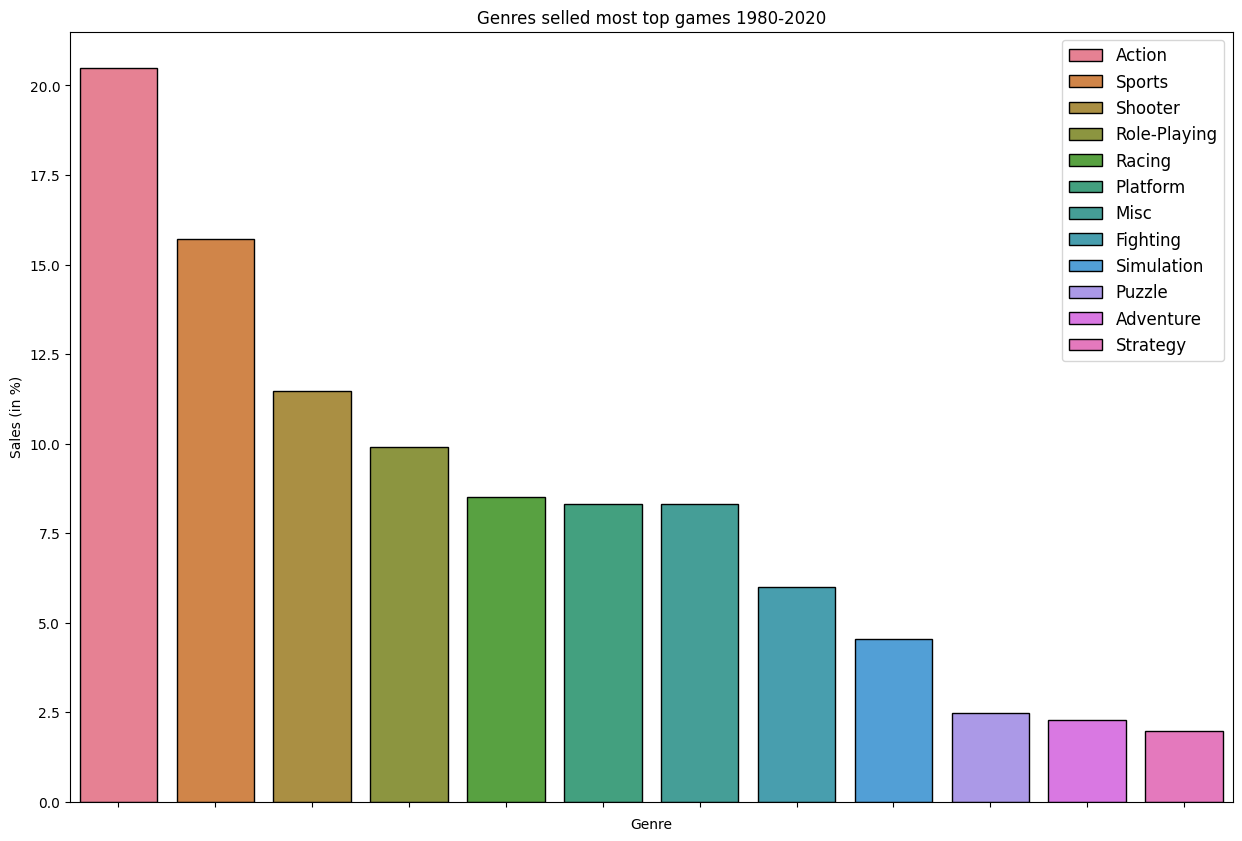

In [12]:
hit_Games_genre= hit_Games['Genre'].value_counts().reset_index()
hit_Games_genre.columns = ['Genre', 'Top_Games_Count']
hit_Games_genre['Top_Games_Count'] = 100*hit_Games_genre['Top_Games_Count']/hit_Games_genre['Top_Games_Count'].sum()

plt.figure(figsize = (15, 10))
sns.set_palette("deep")
sns.barplot(data = hit_Games_genre, x='Genre', y='Top_Games_Count', hue='Genre', edgecolor="black", legend="full").set(xticklabels=[])
plt.legend(loc='best', fontsize=12)
plt.xlabel('Genre')
plt.ylabel('Sales (in %)')
plt.title('Genres selled most top games 1980-2020')
plt.show()

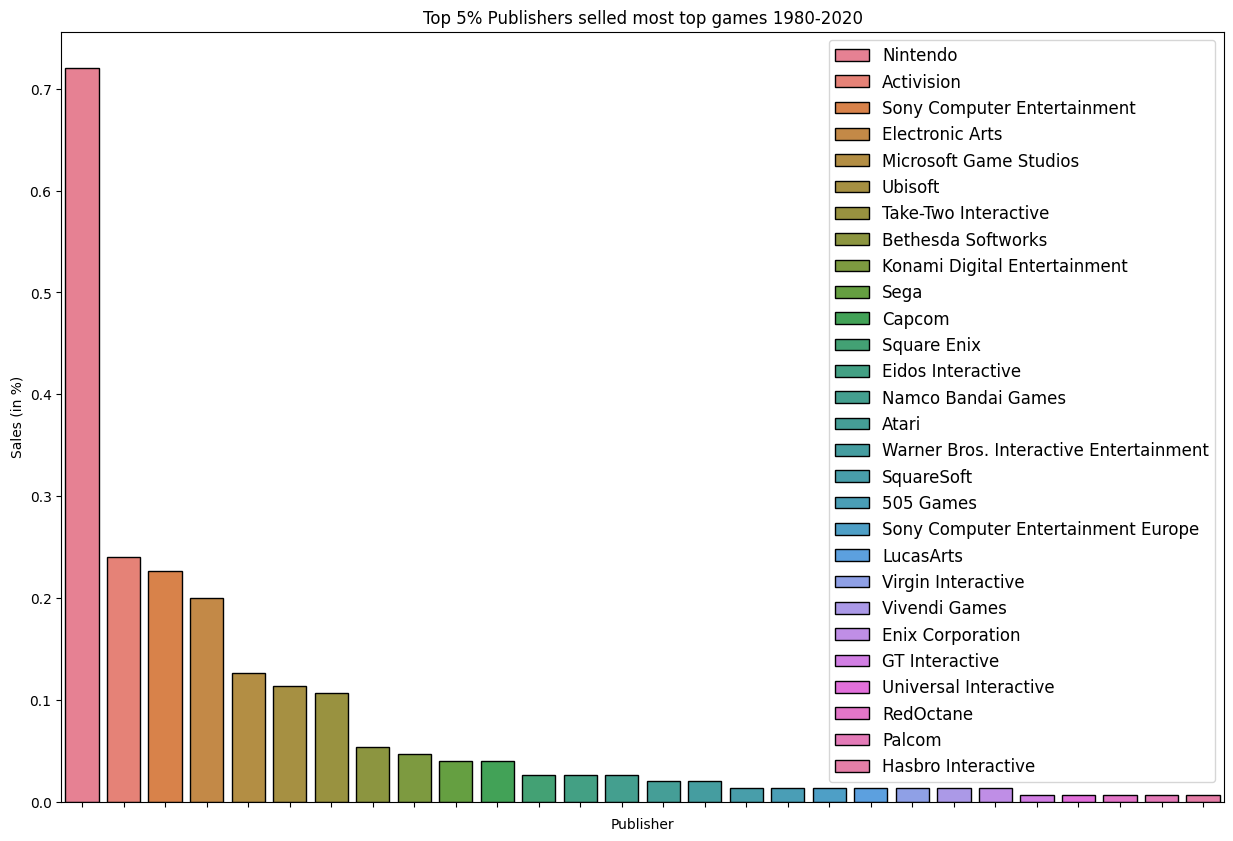

,Publisher,Top_Games_Count
0,Nintendo,0.720000
1,Activision,0.240000
2,Sony Computer Entertainment,0.226667
3,Electronic Arts,0.200000
4,Microsoft Game Studios,0.126667
5,Ubisoft,0.113333
6,Take-Two Interactive,0.106667
7,Bethesda Softworks,0.053333
8,Konami Digital Entertainment,0.046667
9,Sega,0.040000


In [13]:
hit_Games_publisher= hit_Games[hit_Games['Global_Sales'] > hit_Games['Global_Sales'].quantile(0.9)]['Publisher'].value_counts().reset_index()
unhit_Games_publisher = df[df['Global_Sales'] <= df['Global_Sales'].quantile(0.9)]['Publisher'].value_counts().reset_index()

hit_Games_publisher.columns = ['Publisher', 'Top_Games_Count']
unhit_Games_publisher.columns = ['Publisher', 'Top_Games_Count']
other = pd.DataFrame([{'Publisher': 'Other', 'Top_Games_Count': unhit_Games_publisher['Top_Games_Count'].sum()}])

# hit_Games_publisher = pd.concat([hit_Games_publisher, other])

hit_Games_publisher['Top_Games_Count'] = 100*hit_Games_publisher['Top_Games_Count']/(hit_Games_publisher['Top_Games_Count'].sum()
                                                                                     + 1*unhit_Games_publisher['Top_Games_Count'].sum())
plt.figure(figsize = (15, 10))
sns.set_palette("deep")
sns.barplot(data = hit_Games_publisher, x='Publisher', y='Top_Games_Count', hue='Publisher', edgecolor="black", legend="full").set(xticklabels=[])
plt.legend(loc='best', fontsize=12)
plt.xlabel('Publisher')
plt.ylabel('Sales (in %)')
plt.title('Top 5% Publishers selled most top games 1980-2020')
plt.show()
hit_Games_publisher

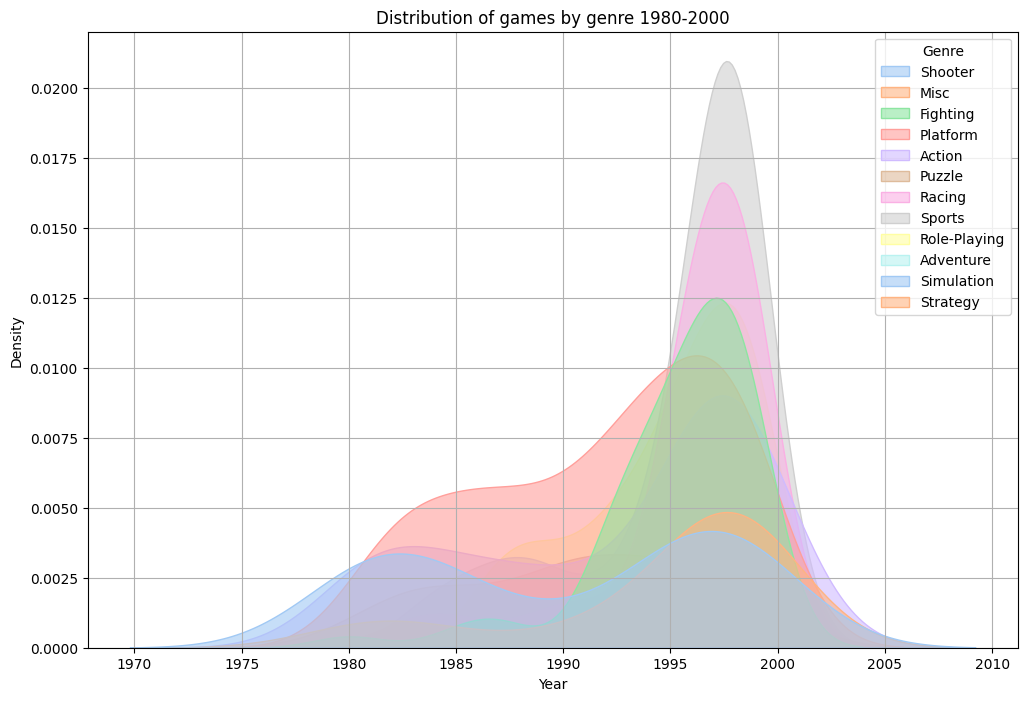

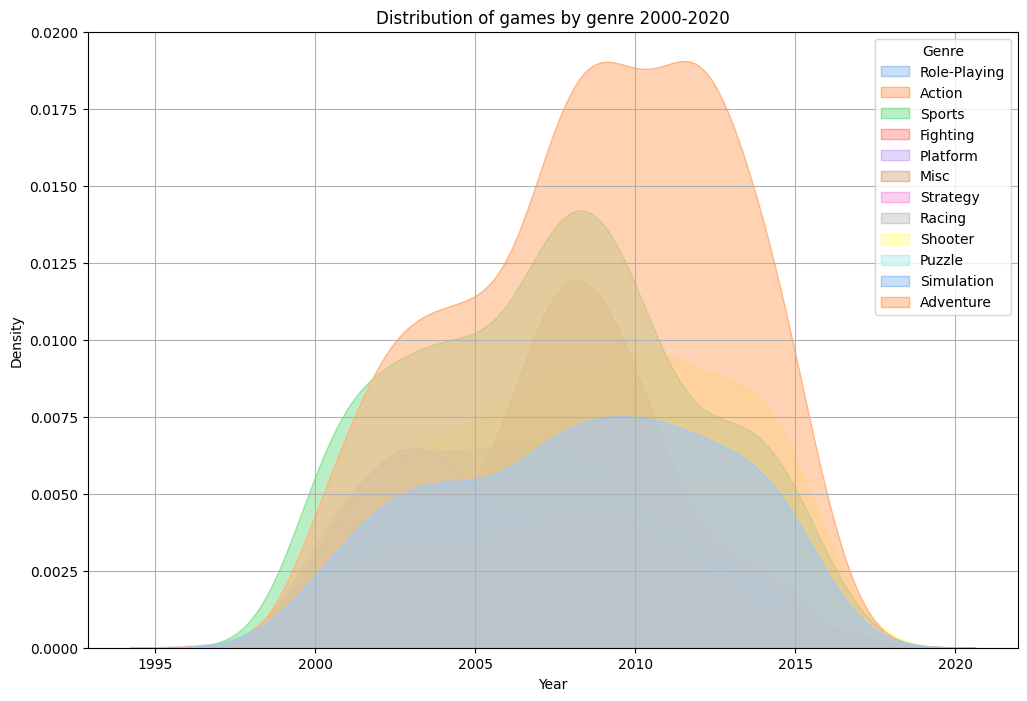

In [14]:
sorted_hit_Games= hit_Games.sort_values(['Year', 'Global_Sales'], ascending=[True, False])

sorted_hit_Games_1980_2000 = sorted_hit_Games[sorted_hit_Games['Year'] < 2000].copy()
sorted_hit_Games_2000 = sorted_hit_Games[sorted_hit_Games['Year'] >= 2000].copy()

### Sorting by genre ###
filter_genre = ['']
if any(filter_genre):
    sorted_hit_Games_1980_2000 = sorted_hit_Games_1980_2000[~sorted_hit_Games_1980_2000['Genre'].isin(filter_genre)]
#########################

plt.figure(figsize = (12, 8))
sns.kdeplot(data=sorted_hit_Games_1980_2000, x='Year', hue='Genre', fill=True, alpha=0.6, palette="pastel")
plt.xlabel('Year')
plt.ylabel('Density')
plt.title('Distribution of games by genre 1980-2000')
plt.grid(True)
plt.show()


### Sorting by genre ###
filter_genre = ['']
if any(filter_genre):
    sorted_hit_Games_2000 = sorted_hit_Games_2000[sorted_hit_Games_2000['Genre'].isin(filter_genre)]
#########################

plt.figure(figsize = (12, 8))
sns.kdeplot(data=sorted_hit_Games_2000, x='Year', hue='Genre', fill=True, alpha=0.6, palette="pastel")
plt.xlabel('Year')
plt.ylabel('Density')
plt.title('Distribution of games by genre 2000-2020')
plt.grid(True)
plt.show()

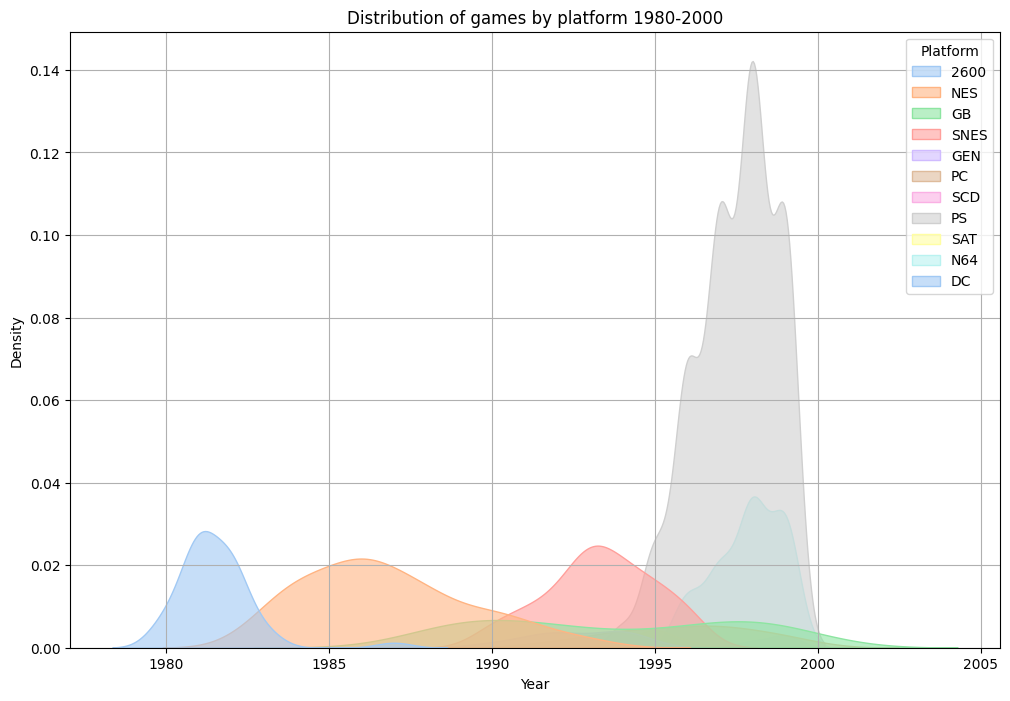

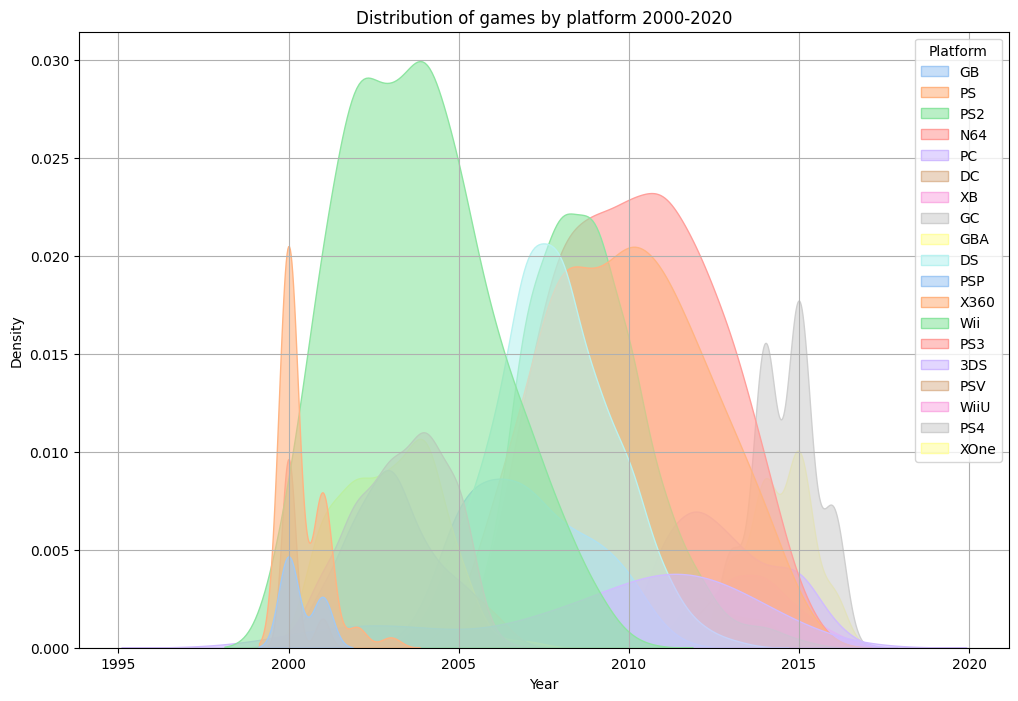

In [15]:
sorted_hit_Games= hit_Games.sort_values(['Year', 'Global_Sales'], ascending=[True, False])

sorted_hit_Games_1980_2000 = sorted_hit_Games[sorted_hit_Games['Year'] < 2000].copy()
sorted_hit_Games_2000 = sorted_hit_Games[sorted_hit_Games['Year'] >= 2000].copy()

### Sorting by genre ###
filter_platform = ['']
if any(filter_platform):
    sorted_hit_Games_1980_2000 = sorted_hit_Games_1980_2000[sorted_hit_Games_1980_2000['Platform'].isin(filter_platform)]
#########################

plt.figure(figsize = (12, 8))
sns.kdeplot(data=sorted_hit_Games_1980_2000, x='Year', hue='Platform', fill=True, alpha=0.6, palette="pastel", warn_singular=False)
plt.xlabel('Year')
plt.ylabel('Density')
plt.title('Distribution of games by platform 1980-2000')
plt.grid(True)
# plt.yscale('log')
plt.show()

sorted_hit_Games_2000 = sorted_hit_Games[sorted_hit_Games['Year'] >= 2000].copy()

### Sorting by genre ###
filter_platform = ['']
if any(filter_platform):
    sorted_hit_Games_2000 = sorted_hit_Games_2000[sorted_hit_Games_2000['Platform'].isin(filter_platform)]
#########################

plt.figure(figsize = (12, 8))
sns.kdeplot(data=sorted_hit_Games_2000, x='Year', hue='Platform', fill=True, alpha=0.6, palette="pastel", warn_singular=False)
plt.xlabel('Year')
plt.ylabel('Density')
plt.title('Distribution of games by platform 2000-2020')
plt.grid(True)
# plt.yscale('log')
plt.show()

## EDA Summary and Main Observations

The exploratory analysis shows that the target variable is not random and that several metadata features are meaningfully related to commercial success.

### 1. Class imbalance is substantial
The `Hit` target represents only a minority of games, while most titles belong to the `not hit` class.  
This means that **overall accuracy alone is not sufficient** for model evaluation, since a model can achieve a high score by mostly predicting the majority class.

### 2. Genre is related to hit probability
The hit rate differs across genres, which suggests that genre contains predictive signal.  
Some genres produce a higher proportion of successful games than others, meaning that genre should be treated as an important categorical feature rather than only as a descriptive label.

### 3. Platform also carries predictive information
The probability of becoming a hit varies across platforms.  
This is expected, since platforms reflect both technological eras and market scale.  
As a result, platform is likely to interact with commercial success through release timing, market size, and audience structure.

### 4. Publisher is a strong but potentially noisy feature
Different publishers show different hit rates, which indicates that publisher identity contains meaningful information about commercial success.  
At the same time, publisher is a high-cardinality feature, so it may improve prediction but also increase the risk of overfitting if not handled carefully.

### 5. Year captures market evolution
The distribution of hit rates over time suggests that the market is not stationary.  
Different years correspond to different console generations, market maturity, and release environments.  
This makes `Year` an important numerical feature and also justifies a **time-based train/test split**.

### 6. The problem is suitable for tabular machine learning
The available predictors are structured metadata:
- release year,
- genre,
- platform,
- publisher.

This means that the task is a **tabular binary classification problem**, not an image or text problem.  
Therefore, classical machine learning models are a natural starting point.

### Interim Conclusion
The EDA suggests that:
- the target is imbalanced,
- the predictors contain real signal,
- the relationship between features and target is likely to be both linear and non-linear,
- and model evaluation must focus on the positive class (`Hit`) rather than on accuracy alone.

## Transition from EDA to Modeling

The exploratory analysis indicates that the metadata features are not equally informative, but they do contain meaningful signal related to commercial success.

At the same time, the analysis also reveals two important modeling challenges:

1. **Class imbalance**  
   Since hit games represent only a minority of observations, model evaluation must focus on positive-class performance and not only on overall accuracy.

2. **Potential feature interactions**  
   The effect of genre, platform, publisher, and release year is unlikely to be purely additive or linear.  
   This motivates comparing both linear and non-linear models.

For this reason, the next step is to move from descriptive analysis to supervised classification and evaluate whether game metadata can be used to identify hit titles in a realistic time-based setting.

In [16]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


hit_point =  df[(df['Year'] >= 1995)&(df['Year'] <= 2007)]['Global_Sales'].quantile(0.8)

df['Hit'] = (df['Global_Sales'] > hit_point).astype(int)

X = df[['Year', 'Genre', 'Platform', 'Publisher']]
Y = df[['Year', 'Hit']]

X_train = X[(X['Year'] >= 1995)&(X['Year'] <= 2007)]
X_test = X[X['Year'] > 2007]

Y_train = Y[(Y['Year'] >= 1995)&(Y['Year'] <= 2007)]['Hit']
Y_test = Y[Y['Year'] > 2007]['Hit']

In [17]:
num_features = ['Year']
cat_features = ['Genre', 'Platform', 'Publisher']

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('cat', cat_pipe, cat_features)
], remainder='drop')


## Why These Models Were Chosen

The model selection strategy was based on the structure of the dataset and the nature of the task.

### 1. DummyClassifier — baseline reference
A baseline model is necessary to verify that the prediction task contains real signal.  
The DummyClassifier provides a minimal reference point and shows how a naive strategy performs without learning meaningful relationships from the data.

### 2. Logistic Regression — interpretable linear baseline
Logistic Regression was chosen as the first real model because it is:
- simple,
- interpretable,
- widely used for binary classification,
- and well suited as a baseline for tabular data.

It helps answer an important question:
> Is there a useful linear signal in the metadata?

If Logistic Regression performs better than the dummy baseline, then the features already contain informative structure.

### 3. Random Forest — non-linear tree-based model
Random Forest was included because the relationship between metadata and commercial success is unlikely to be purely linear.  
For example:
- the effect of platform may depend on year,
- the effect of publisher may vary by genre,
- and some feature interactions may be hard to capture with a linear model.

Random Forest helps test whether non-linear decision boundaries improve hit detection.

### 4. Balanced versions — response to class imbalance
Since the `Hit` class is a minority class, standard models may become too conservative and predict mostly `not hit`.  
To address this, balanced versions of Logistic Regression and Random Forest were tested using class weights.

This makes sense because the practical goal of the project is not only to classify the majority class correctly, but also to recover commercially successful games.

### 5. CatBoost — strong model for tabular categorical data
CatBoost was selected because the dataset contains several categorical features with potentially complex interactions:
- genre,
- platform,
- publisher.

CatBoost is especially well suited for this type of tabular problem and serves as a stronger model for comparison against simpler baselines.

### Modeling Logic
The selected model set follows a clear progression:

1. **DummyClassifier** — naive baseline  
2. **Logistic Regression** — simple interpretable baseline  
3. **Random Forest** — non-linear tree-based model  
4. **Balanced variants** — class-imbalance-aware versions  
5. **CatBoost** — stronger tabular model

This progression makes it possible to compare:
- naive vs learned behavior,
- linear vs non-linear modeling,
- unbalanced vs class-balanced training,
- and baseline models vs stronger tabular boosting methods.

              precision    recall  f1-score   support

           0       0.83      0.99      0.90      6582
           1       0.62      0.04      0.07      1411

    accuracy                           0.83      7993
   macro avg       0.72      0.52      0.49      7993
weighted avg       0.79      0.83      0.76      7993



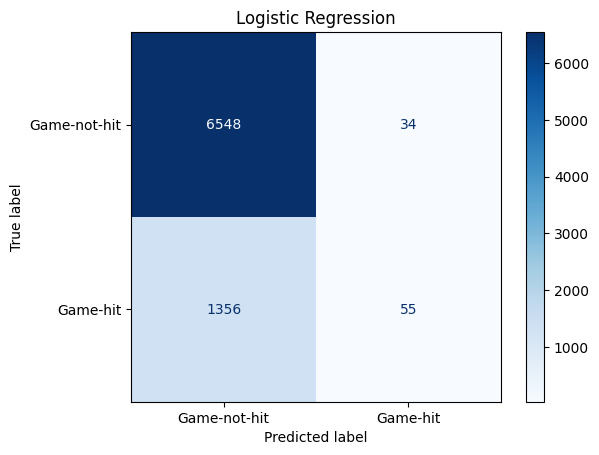

ROC AUC Score: 0.7648


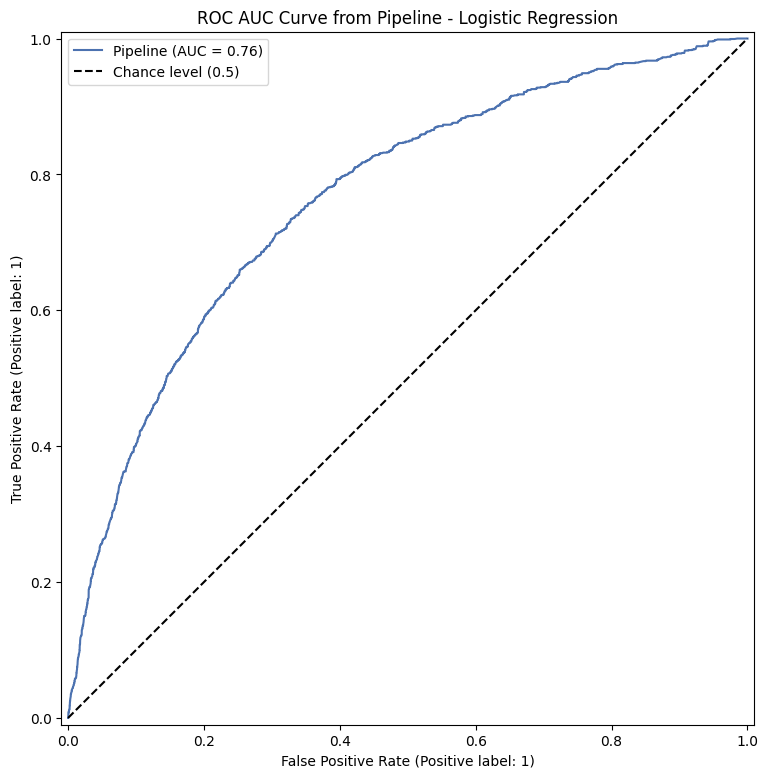

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, RocCurveDisplay

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=4000))
])

pipeline.fit(X_train, Y_train)
Y_log_reg = pipeline.predict(X_test)

print(classification_report(Y_test, Y_log_reg))

cm = confusion_matrix(Y_test, Y_log_reg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Game-not-hit', 'Game-hit'])

disp.plot(cmap=plt.cm.Blues)
plt.title('Logistic Regression')
plt.show()

Y_probs = pipeline.predict_proba(X_test)[:, 1]
score_log_reg = roc_auc_score(Y_test, Y_probs)
print(f"ROC AUC Score: {score_log_reg:.4f}")

fig, ax = plt.subplots(figsize=(9, 9))
RocCurveDisplay.from_estimator(pipeline, X_test, Y_test,  ax=ax)
plt.title("ROC AUC Curve from Pipeline - Logistic Regression")
plt.plot([0, 1], [0, 1], "k--", label="Chance level (0.5)") # Add reference line
plt.legend()
plt.show()

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      6582
           1       0.19      0.21      0.20      1411

    accuracy                           0.70      7993
   macro avg       0.51      0.51      0.51      7993
weighted avg       0.72      0.70      0.71      7993



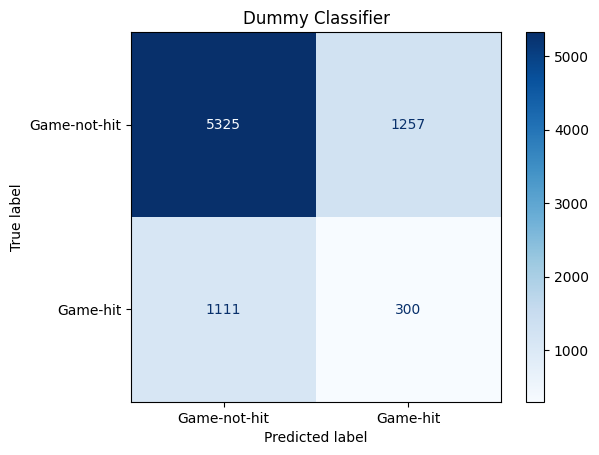

ROC AUC Score: 0.4934


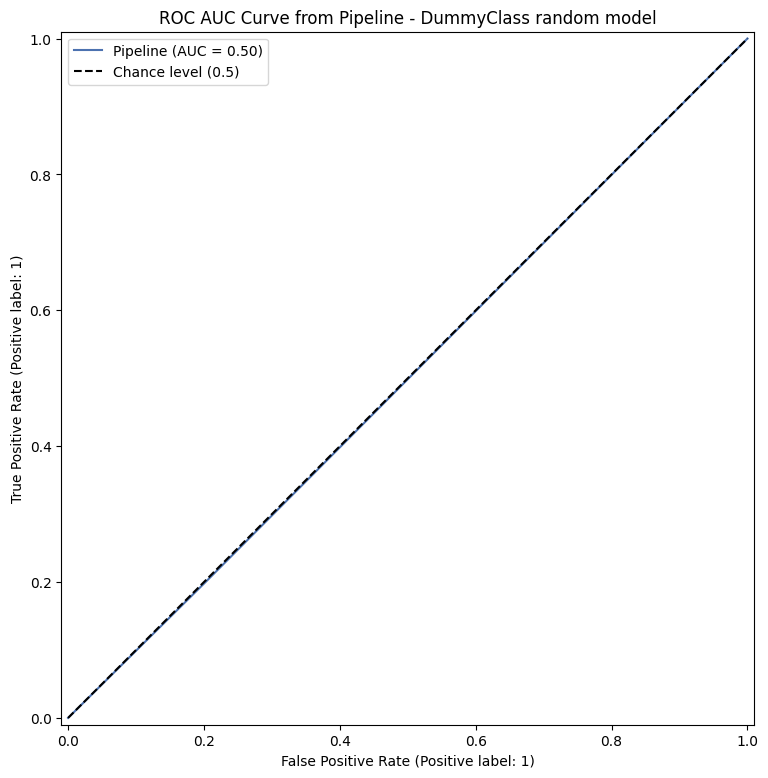

In [25]:
from sklearn.dummy import DummyClassifier

pipeline = Pipeline([
    ('prep', preprocessor),       # Preprocessing step
    ('dummy', DummyClassifier(strategy='stratified')) # Baseline classifier
])

# Fit and predict just like any other model
pipeline.fit(X_train, Y_train)
Dummy_Y_prep = pipeline.predict(X_test)

print(classification_report(Y_test, Dummy_Y_prep))

cm_dummy = confusion_matrix(Y_test, Dummy_Y_prep)

disp = ConfusionMatrixDisplay(confusion_matrix = cm_dummy, display_labels=['Game-not-hit', 'Game-hit'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Dummy Classifier')
plt.show()

Y_probs = pipeline.predict_proba(X_test)[:, 1]
score_DummyClass = roc_auc_score(Y_test, Y_probs)
print(f"ROC AUC Score: {score_DummyClass:.4f}")

fig, ax = plt.subplots(figsize=(9, 9))
RocCurveDisplay.from_estimator(pipeline, X_test, Y_test,  ax=ax)
plt.title("ROC AUC Curve from Pipeline - DummyClass random model")
plt.plot([0, 1], [0, 1], "k--", label="Chance level (0.5)") # Add reference line
plt.legend()
plt.show()

              precision    recall  f1-score   support

           0       0.85      0.92      0.89      6582
           1       0.41      0.25      0.31      1411

    accuracy                           0.80      7993
   macro avg       0.63      0.59      0.60      7993
weighted avg       0.77      0.80      0.78      7993



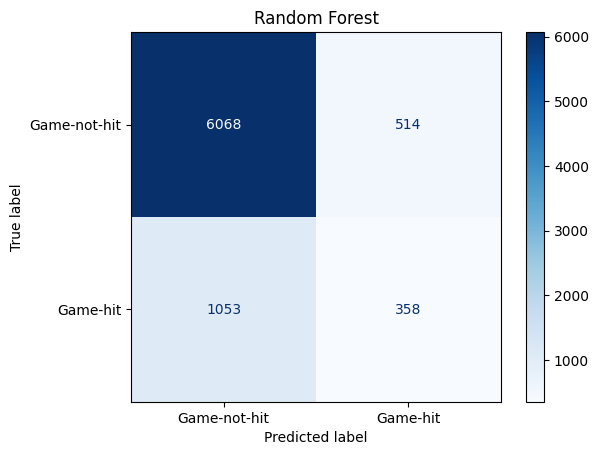

ROC AUC Score: 0.6995


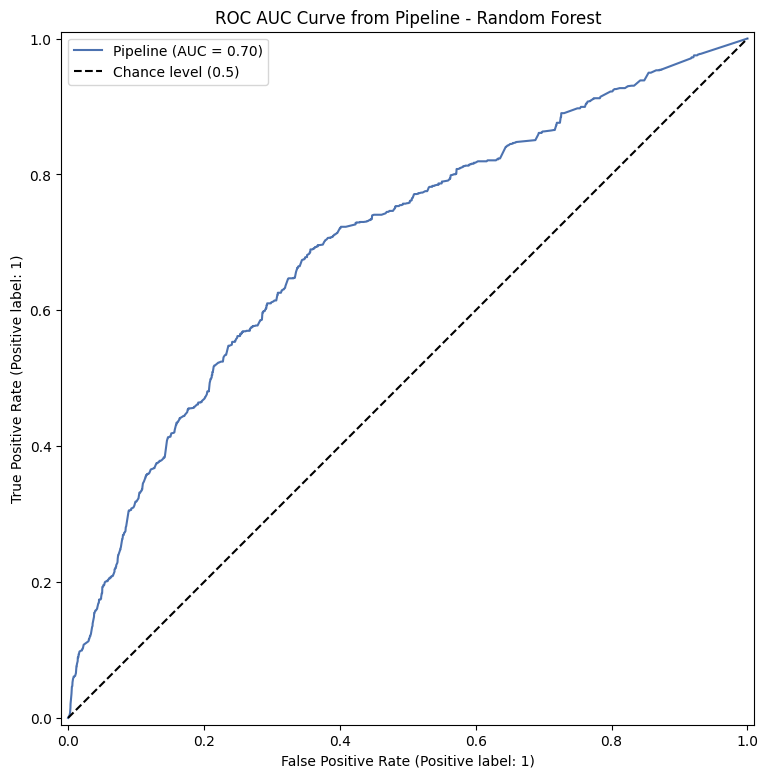

In [20]:
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('prep', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Fit the entire pipeline on training data
pipeline.fit(X_train, Y_train)
Y_pred_forest = pipeline.predict(X_test)

print(classification_report(Y_test, Y_pred_forest))

cm_forest = confusion_matrix(Y_test, Y_pred_forest)

disp = ConfusionMatrixDisplay(confusion_matrix = cm_forest, display_labels=['Game-not-hit', 'Game-hit'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Random Forest')
plt.show()

Y_probs = pipeline.predict_proba(X_test)[:, 1]
score_RandForest = roc_auc_score(Y_test, Y_probs)
print(f"ROC AUC Score: {score_RandForest:.4f}")

fig, ax = plt.subplots(figsize=(9, 9))
RocCurveDisplay.from_estimator(pipeline, X_test, Y_test,  ax=ax)
plt.title("ROC AUC Curve from Pipeline - Random Forest")
plt.plot([0, 1], [0, 1], "k--", label="Chance level (0.5)") # Add reference line
plt.legend()
plt.show()

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      6582
           1       0.42      0.46      0.44      1411

    accuracy                           0.79      7993
   macro avg       0.65      0.66      0.66      7993
weighted avg       0.80      0.79      0.80      7993



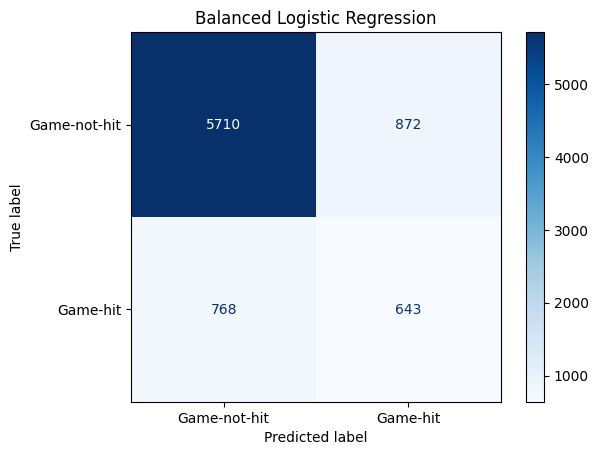

ROC AUC Score: 0.7562


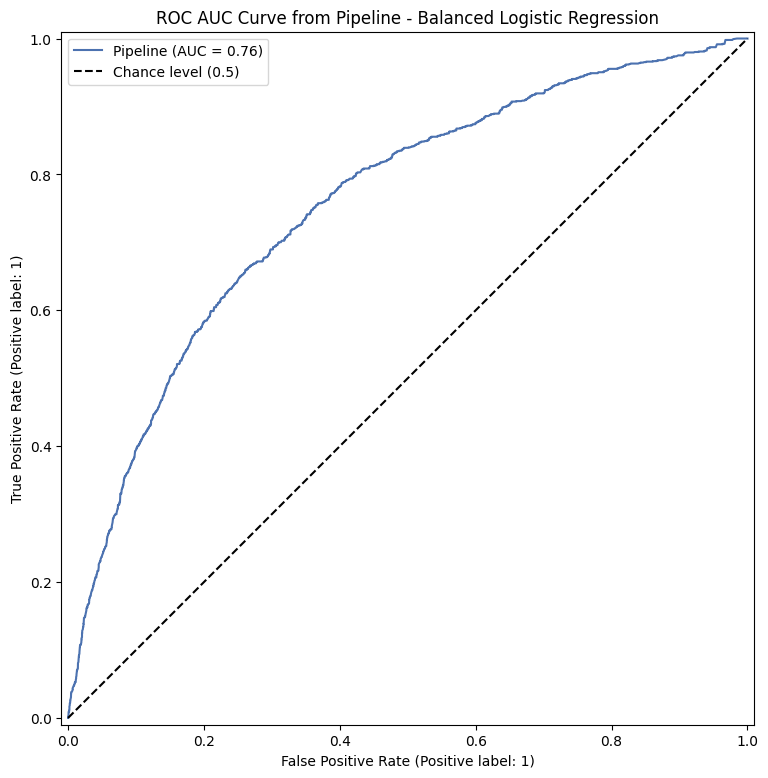

In [21]:
pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=4000, class_weight='balanced'))
])

pipeline.fit(X_train, Y_train)
Y_log_reg_bal = pipeline.predict(X_test)

print(classification_report(Y_test, Y_log_reg_bal))

cm = confusion_matrix(Y_test, Y_log_reg_bal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Game-not-hit', 'Game-hit'])

disp.plot(cmap=plt.cm.Blues)
plt.title('Balanced Logistic Regression')
plt.show()

Y_probs = pipeline.predict_proba(X_test)[:, 1]
score_log_reg_balanced = roc_auc_score(Y_test, Y_probs)
print(f"ROC AUC Score: {score_log_reg_balanced:.4f}")

fig, ax = plt.subplots(figsize=(9, 9))
RocCurveDisplay.from_estimator(pipeline, X_test, Y_test,  ax=ax)
plt.title("ROC AUC Curve from Pipeline - Balanced Logistic Regression")
plt.plot([0, 1], [0, 1], "k--", label="Chance level (0.5)") # Add reference line
plt.legend()
plt.show()

              precision    recall  f1-score   support

           0       0.87      0.86      0.86      6582
           1       0.38      0.40      0.39      1411

    accuracy                           0.78      7993
   macro avg       0.62      0.63      0.63      7993
weighted avg       0.78      0.78      0.78      7993



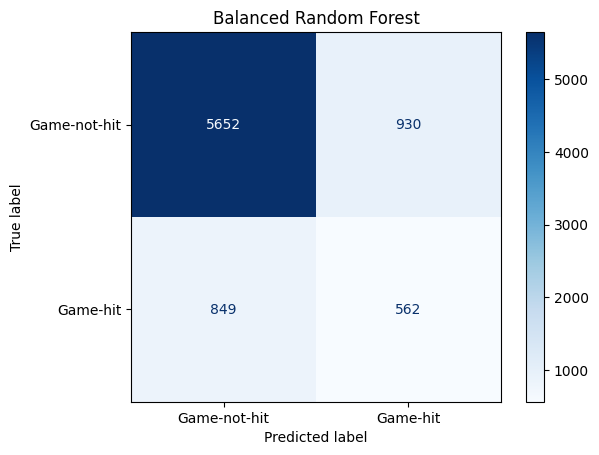

ROC AUC Score: 0.7020


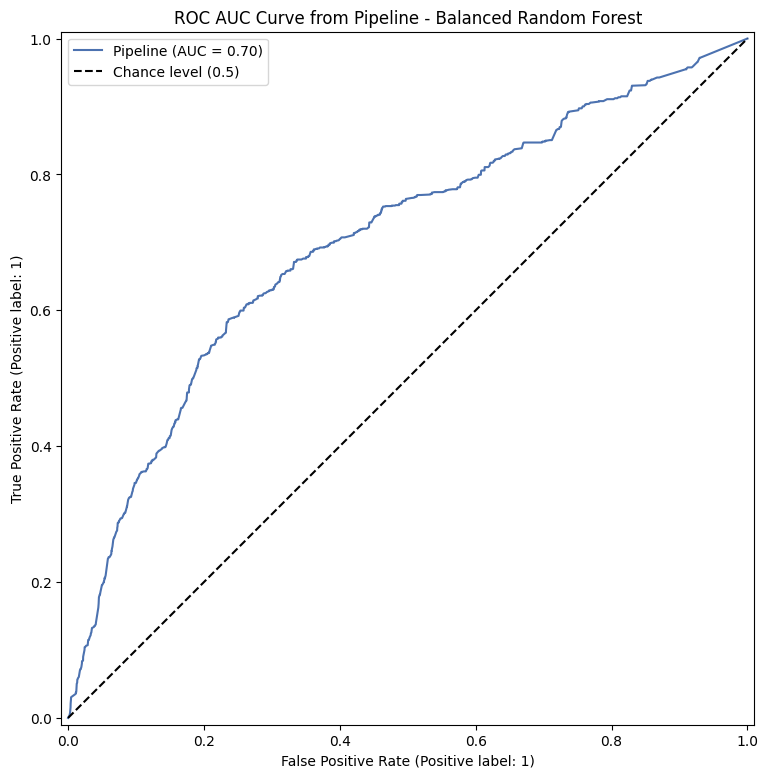

In [22]:
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('prep', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

# Fit the entire pipeline on training data
pipeline.fit(X_train, Y_train)
Y_pred_forest_bal = pipeline.predict(X_test)

print(classification_report(Y_test, Y_pred_forest_bal))

cm_forest = confusion_matrix(Y_test, Y_pred_forest_bal)

disp = ConfusionMatrixDisplay(confusion_matrix = cm_forest, display_labels=['Game-not-hit', 'Game-hit'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Balanced Random Forest')
plt.show()

Y_probs = pipeline.predict_proba(X_test)[:, 1]
score_RandForest_balanced = roc_auc_score(Y_test, Y_probs)
print(f"ROC AUC Score: {score_RandForest_balanced:.4f}")

fig, ax = plt.subplots(figsize=(9, 9))
RocCurveDisplay.from_estimator(pipeline, X_test, Y_test,  ax=ax)
plt.title("ROC AUC Curve from Pipeline - Balanced Random Forest")
plt.plot([0, 1], [0, 1], "k--", label="Chance level (0.5)") # Add reference line
plt.legend()
plt.show()

              precision    recall  f1-score   support

           0       0.85      0.96      0.90      6582
           1       0.56      0.23      0.33      1411

    accuracy                           0.83      7993
   macro avg       0.71      0.60      0.62      7993
weighted avg       0.80      0.83      0.80      7993



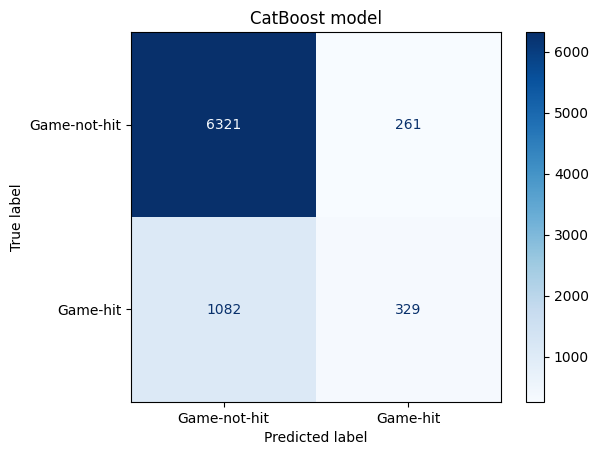

ROC AUC Score: 0.7761


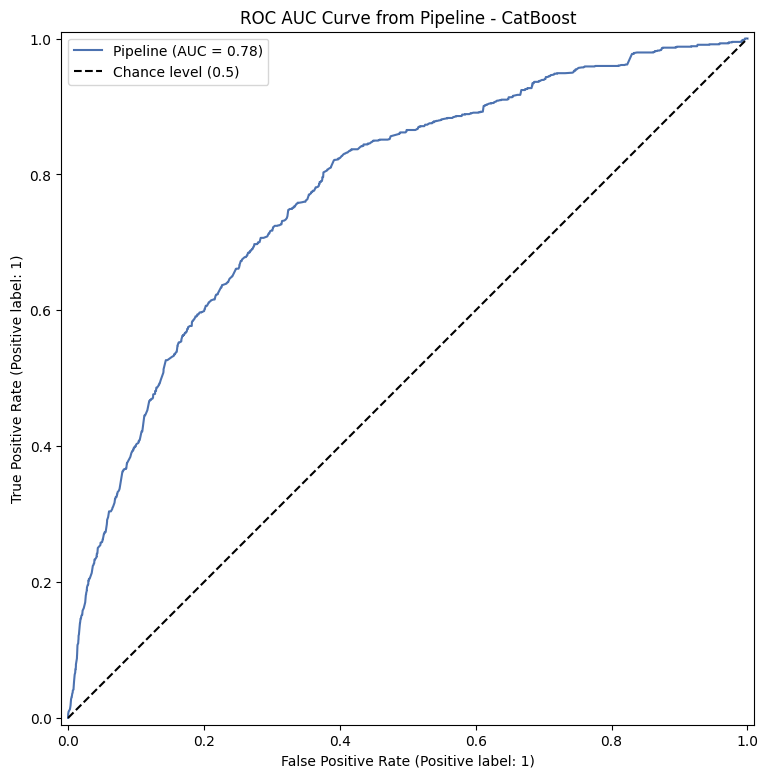

In [23]:
from catboost import CatBoostClassifier

numeric_features = ['Year']
categorical_features = ['Genre', 'Platform', 'Publisher']

pipeline = Pipeline(steps=[
    ('model', CatBoostClassifier(iterations=1000, verbose=False))
])

pipeline.fit(X_train, Y_train, model__cat_features = categorical_features)
Y_catboost = pipeline.predict(X_test)

print(classification_report(Y_test, Y_catboost))

cm_catboost = confusion_matrix(Y_test, Y_catboost)

disp = ConfusionMatrixDisplay(confusion_matrix = cm_catboost, display_labels=['Game-not-hit', 'Game-hit'])
disp.plot(cmap=plt.cm.Blues)
plt.title('CatBoost model')
plt.show()

Y_probs = pipeline.predict_proba(X_test)[:, 1]
score_CatBoost = roc_auc_score(Y_test, Y_probs)
print(f"ROC AUC Score: {score_CatBoost:.4f}")

fig, ax = plt.subplots(figsize=(9, 9))
RocCurveDisplay.from_estimator(pipeline, X_test, Y_test,  ax=ax)
plt.title("ROC AUC Curve from Pipeline - CatBoost")
plt.plot([0, 1], [0, 1], "k--", label="Chance level (0.5)") # Add reference line
plt.legend()
plt.show()

## Why Accuracy Is Not Enough

Because the target is imbalanced, a model can achieve high accuracy by mostly predicting the majority class (`not hit`).

For that reason, model evaluation should focus not only on **Accuracy**, but also on:
- **Precision (Hit)** — how reliable positive predictions are,
- **Recall (Hit)** — how many real hit games are successfully detected,
- **F1-score (Hit)** — the balance between precision and recall,
- **ROC-AUC** — the overall ranking quality of the model.

This is especially important in this project, since the practical goal is to identify successful games rather than simply classify the majority class correctly.

## Model Performance Comparison
Since the target is imbalanced, **F1-score** and **ROC-AUC** are more informative than accuracy alone.

In [24]:
from prettytable import PrettyTable
from sklearn.metrics import classification_report, roc_auc_score

# classification_report уже есть
report_log_reg = classification_report(Y_test, Y_log_reg, output_dict=True)
report_RandForest = classification_report(Y_test, Y_pred_forest, output_dict=True)
report_DummyClass = classification_report(Y_test, Dummy_Y_prep, output_dict=True)
report_log_reg_balanced = classification_report(Y_test, Y_log_reg_bal, output_dict=True)
report_RandForest_balanced = classification_report(Y_test, Y_pred_forest_bal, output_dict=True)
report_CatBoost = classification_report(Y_test, Y_catboost, output_dict=True)

pos_class = '1'

x = PrettyTable()
x.field_names = ['Model', 'Accuracy', 'Precision (Hit)', 'Recall (Hit)', 'F1 (Hit)', 'ROC-AUC']

models = [
    ('LogReg', report_log_reg, score_log_reg),
    ('RandomForest', report_RandForest, score_RandForest),
    ('DummyClassifier', report_DummyClass, score_DummyClass),
    ('LogReg balanced', report_log_reg_balanced, score_log_reg_balanced),
    ('RandomForest balanced', report_RandForest_balanced, score_RandForest_balanced),
    ('CatBoost', report_CatBoost, score_CatBoost),
]

for model_name, report, roc_auc in models:
    x.add_row([
        model_name,
        round(report['accuracy'], 3),
        round(report[pos_class]['precision'], 3),
        round(report[pos_class]['recall'], 3),
        round(report[pos_class]['f1-score'], 3),
        round(roc_auc, 3)
    ])

x.align['Model'] = 'l'
x.align['Accuracy'] = 'r'
x.align['Precision (Hit)'] = 'r'
x.align['Recall (Hit)'] = 'r'
x.align['F1 (Hit)'] = 'r'
x.align['ROC-AUC'] = 'r'

print(x)

+-----------------------+----------+-----------------+--------------+----------+---------+
| Model                 | Accuracy | Precision (Hit) | Recall (Hit) | F1 (Hit) | ROC-AUC |
+-----------------------+----------+-----------------+--------------+----------+---------+
| LogReg                |    0.826 |           0.618 |        0.039 |    0.073 |   0.765 |
| RandomForest          |    0.804 |           0.411 |        0.254 |    0.314 |     0.7 |
| DummyClassifier       |    0.687 |           0.171 |          0.2 |    0.184 |   0.487 |
| LogReg balanced       |    0.795 |           0.424 |        0.456 |     0.44 |   0.756 |
| RandomForest balanced |    0.777 |           0.377 |        0.398 |    0.387 |   0.702 |
| CatBoost              |    0.832 |           0.558 |        0.233 |    0.329 |   0.776 |
+-----------------------+----------+-----------------+--------------+----------+---------+


## Model Comparison Conclusions

The results are consistent with an imbalanced binary classification setup.

A standard **Logistic Regression** model achieves high overall accuracy, but its recall on the positive class is extremely low. This means that the model is strongly biased toward predicting the majority class and misses most hit games.

**Random Forest** improves detection of the positive class and provides a better balance between non-hit and hit prediction, although its overall ranking quality remains below the strongest model.

Applying **class balancing** substantially improves performance on the hit class. In particular, **balanced Logistic Regression** achieves the best balance between precision and recall for identifying hit games and delivers the strongest F1-score on the positive class.

At the same time, **CatBoost** achieves the best overall **Accuracy** and **ROC-AUC**, which suggests that it is the strongest model in terms of general ranking quality and overall classification performance.

Overall, the experiments show that:
- video game metadata contains meaningful predictive signal,
- class imbalance strongly affects model behavior,
- the best model depends on the objective:
  - **Balanced Logistic Regression** is the best choice for hit detection,
  - **CatBoost** is the best choice for overall predictive performance and ranking quality.

# Final Conclusion

This project shows that commercial success in the video game market can be predicted to a certain extent using only tabular metadata such as **release year, genre, platform, and publisher**.

The results also highlight an important modeling issue: because the target class is imbalanced, high overall accuracy does not necessarily mean that a model is good at identifying hit games. This is clearly demonstrated by standard Logistic Regression, which achieves strong accuracy but fails to recover most positive cases.

Among the tested models, **Balanced Logistic Regression** provides the most useful trade-off for detecting hit games specifically, while **CatBoost** delivers the best overall predictive quality according to Accuracy and ROC-AUC.

In practical terms, the project confirms that pre-release or release-time metadata contains a meaningful but limited signal of commercial success. Stronger prediction would likely require richer features such as franchise information, critic/user signals, marketing variables, or regional launch context.